In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import mne
from src.preprocessing.loader import load_raw
from src.preprocessing.filter import apply_filters, make_epochs
from src.analysis.features import compute_itc, compute_tfr
from src.visualization.plot import plot_itc, plot_tfr
from pipeline import load_config

cfg = load_config("../config.yaml")
print("Imports OK")

Imports OK


In [2]:
sample_path = mne.datasets.sample.data_path()
raw_path = sample_path / "MEG" / "sample" / "sample_audvis_raw.fif"

raw = load_raw(str(raw_path))
raw = raw.copy().pick_types(eeg=True, meg=False, stim=True, eog=True)
bp = cfg["preprocessing"]["bandpass"]
raw = apply_filters(raw, l_freq=bp["l_freq"], h_freq=bp["h_freq"], notch_freq=cfg["preprocessing"]["notch_freq"])

# Same epoch window as the M7 notebook, and for the same reason: compute_itc
# leans on the identical Morlet wavelet machinery (n_cycles=7) as compute_tfr,
# so the lowest analyzed frequency (4 Hz) needs several seconds of signal for
# its wavelet to fit inside the epoch without running off the edge. tmax=3.0
# (a 3.3s window with tmin=-0.3) gives that headroom -- config.yaml's stock
# epoch_tmin/epoch_tmax (-0.2/0.8) is too short at this frequency floor, so
# this notebook keeps the same local override M7 used instead of the config
# default. Using the identical window (and the identical full set of
# conditions, not just one) also keeps this notebook's ITC plot and M7's
# power plot directly comparable cell-for-cell.
epochs = make_epochs(raw, tmin=-0.3, tmax=3.0)

print(f"Total epochs: {len(epochs)}")
print(f"Conditions: {list(epochs.event_id.keys())}")

Opening raw data file C:\Users\ke725\mne_data\MNE-sample-data\MEG\sample\sample_audvis_raw.fif...


    Read a total of 3 projection items:


        PCA-v1 (1 x 102)  idle


        PCA-v2 (1 x 102)  idle


        PCA-v3 (1 x 102)  idle


...

Applying baseline correction (mode: mean)


0 projection items activated


Using data from preloaded Raw for 320 events and 1983 original time points ...


0 bad epochs dropped


Total epochs: 320
Conditions: ['auditory/left', 'auditory/right', 'visual/left', 'visual/right', 'smiley', 'buttonpress']


In [3]:
# theta through the top of this project's gamma band (config.yaml's
# frequency_bands) -- same range M7 used, but stepped by 2 Hz instead of 1.
# Full per-trial complex ITC tracking is far more expensive than compute_tfr's
# power-only path (MNE has to hold onto every trial's complex wavelet
# coefficient before combining phases, not just square-and-average), so
# halving the frequency count keeps this notebook's runtime reasonable while
# still covering the identical range M7's power plot used -- the axes stay
# directly comparable, just coarser.
bands = cfg["analysis"]["frequency_bands"]
freq_min = bands["theta"][0]
freq_max = bands["gamma"][1]
freqs = np.arange(freq_min, freq_max, 2)

print(f"Frequency range: {freqs[0]}-{freqs[-1]} Hz, {len(freqs)} frequencies")

Frequency range: 4-38 Hz, 18 frequencies


In [4]:
# Computing ITC across every channel, frequency, and trial takes noticeably
# longer than compute_tfr on the same epochs -- MNE has to track the full
# complex-valued wavelet coefficient per trial before combining phases,
# instead of just squaring the magnitude and discarding phase. Let it run.
itc = compute_itc(epochs, freqs=freqs)

print(type(itc))
print(f"ITC data shape (channels, freqs, times): {itc.data.shape}")

NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


<class 'mne.time_frequency.tfr.AverageTFR'>
ITC data shape (channels, freqs, times): (59, 18, 1983)


No baseline correction applied


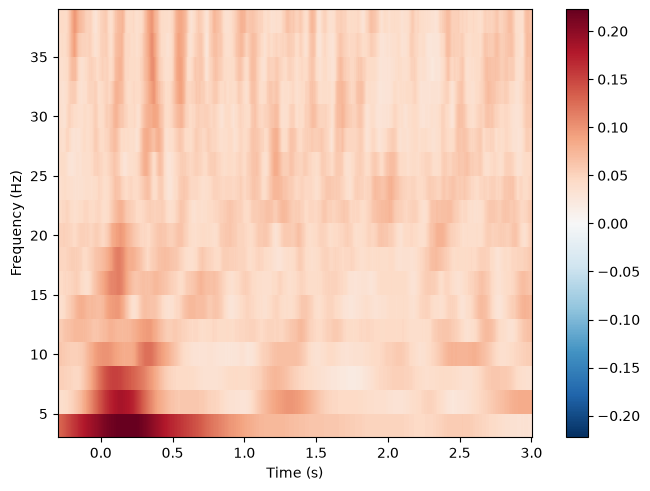

In [5]:
# First look, uncorrected -- color scale should sit in [0, 1], not the
# unbounded dB-like range a power plot would show. Baseline correction
# comes in the next cell.
plot_itc(itc, fmin=freq_min, fmax=freq_max)

Applying baseline correction (mode: mean)


No baseline correction applied


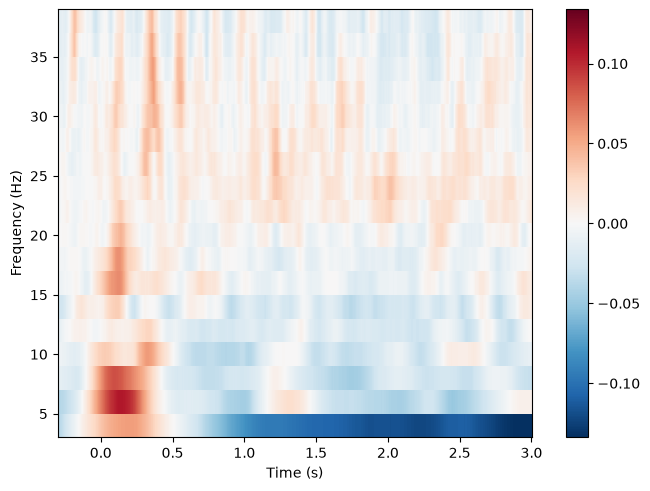

In [6]:
# mode="mean" instead of "logratio": ITC is already bounded 0-1, so
# subtracting the pre-stimulus baseline mean is directly interpretable as
# "how much phase-locking rose above its pre-stimulus level," which reads
# more naturally here than a log ratio (used for the power plot below).
itc_bc = itc.copy().apply_baseline(baseline=(-0.3, 0), mode="mean")
plot_itc(itc_bc, fmin=freq_min, fmax=freq_max)

NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


Applying baseline correction (mode: logratio)


Applying baseline correction (mode: logratio)


C:\Users\ke725\Documents\eeg-project\.venv\Lib\site-packages\mne\time_frequency\tfr.py:2086: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  figs = [plt.figure(layout="constrained") for _ in range(data.shape[0])]


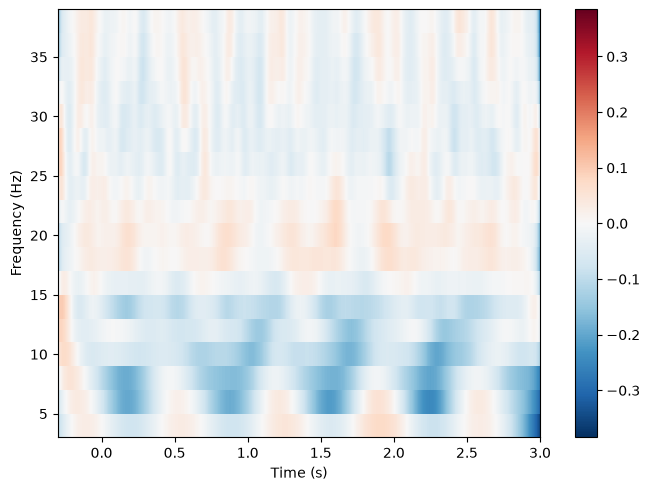

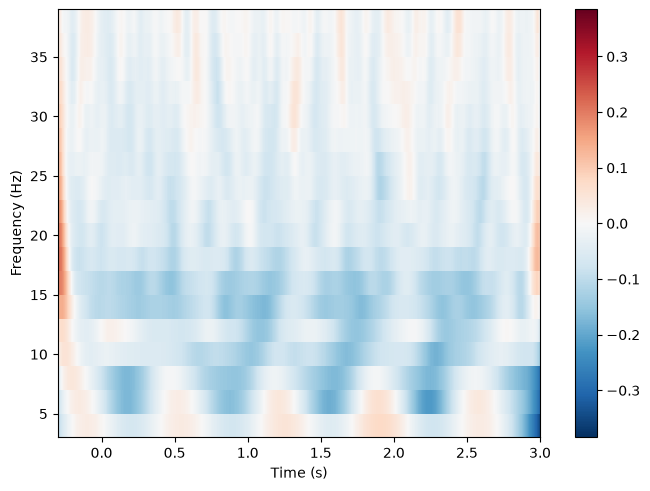

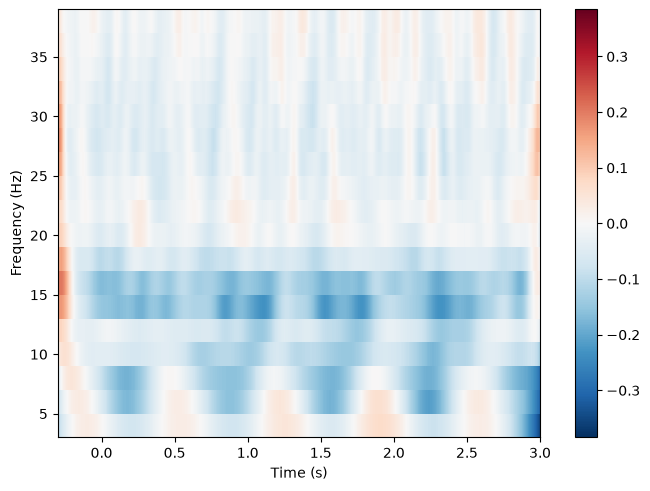

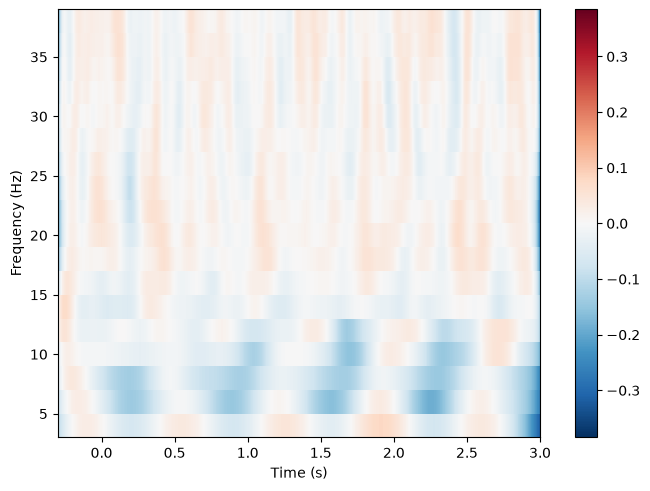

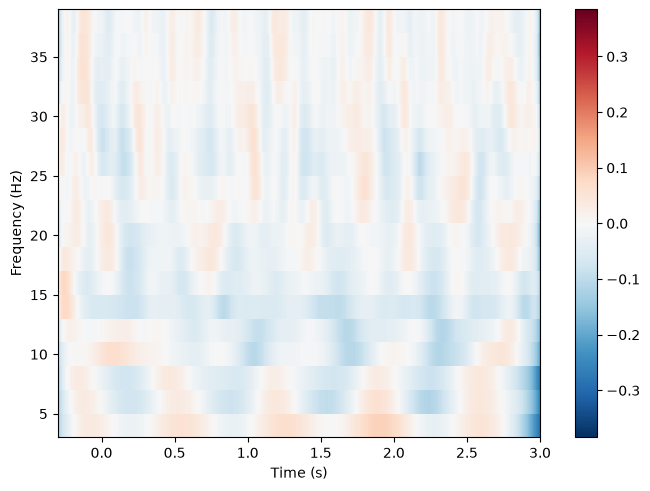

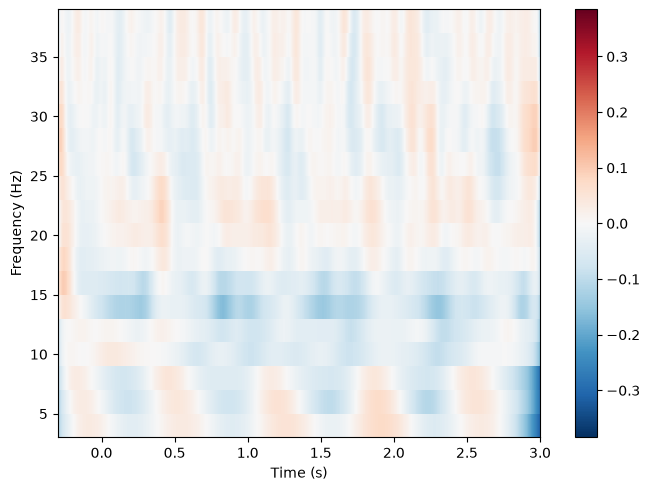

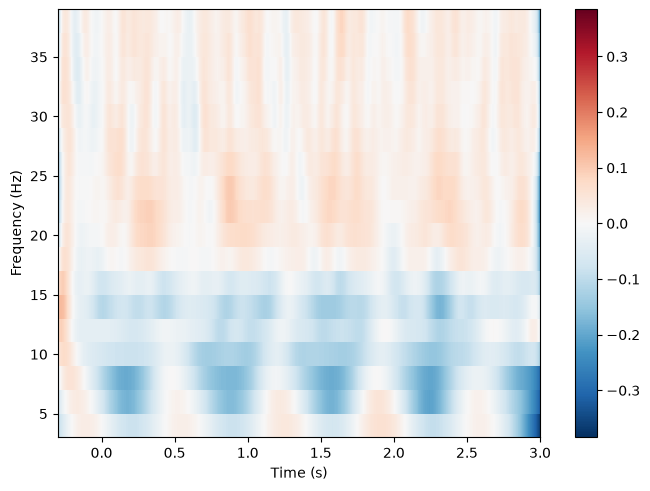

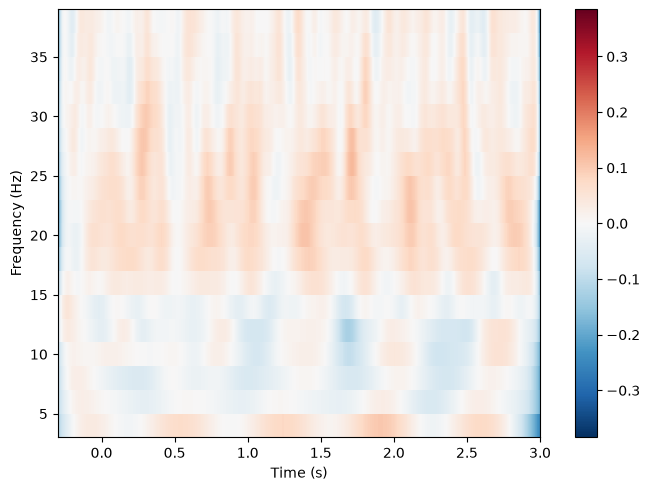

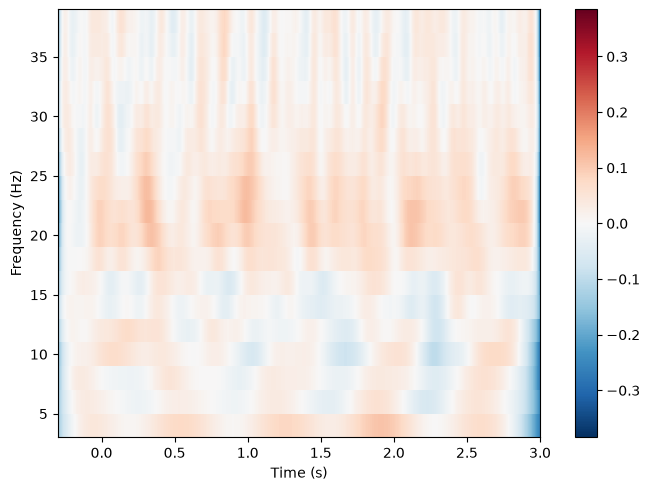

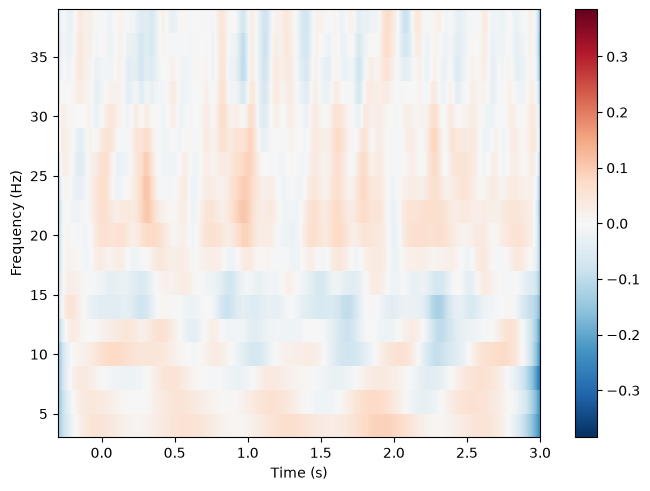

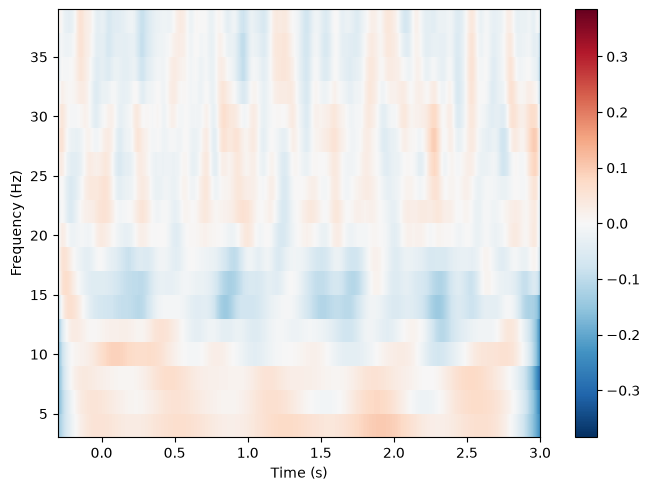

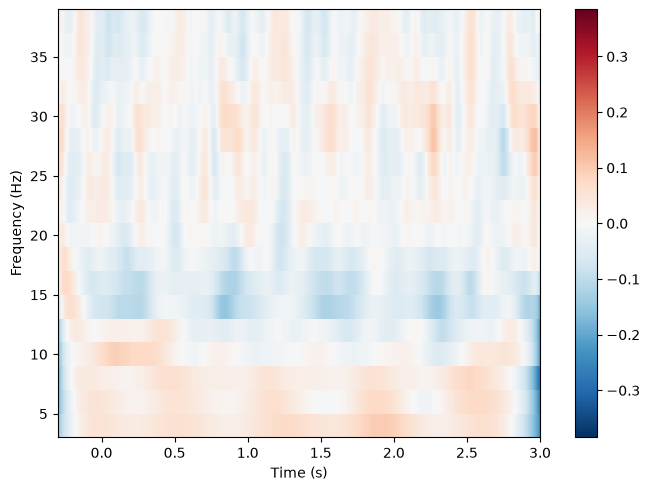

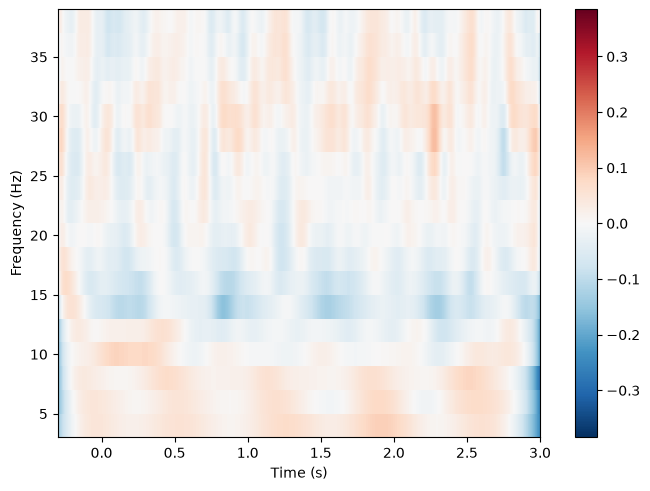

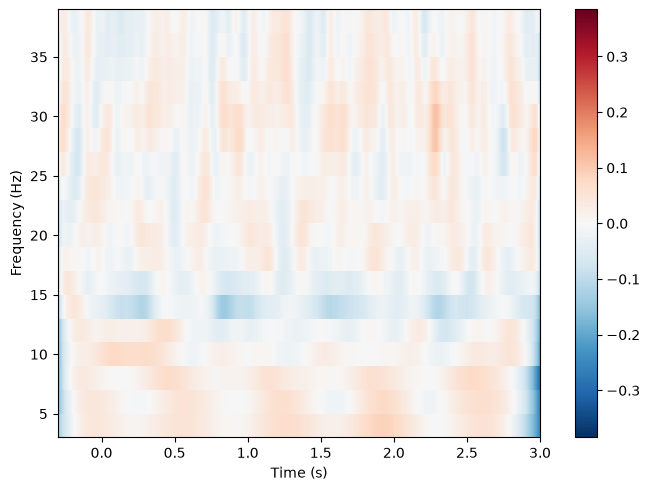

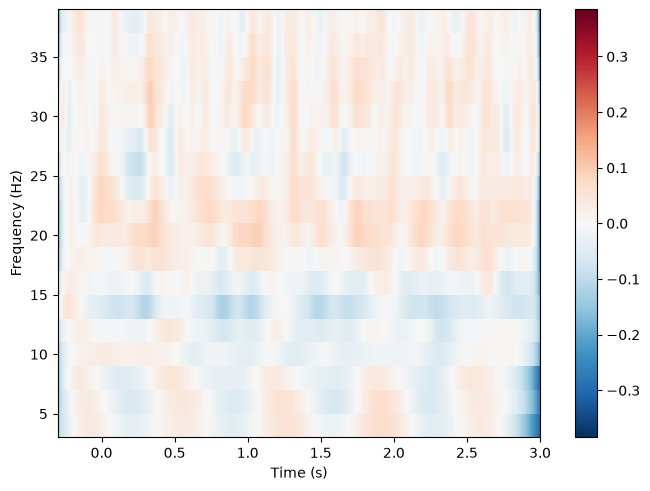

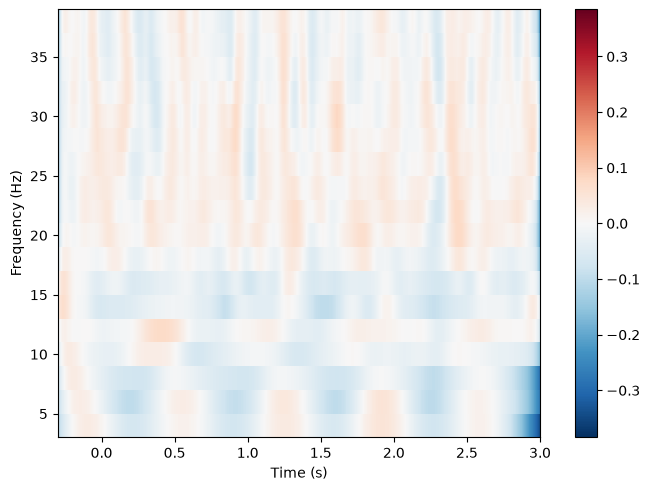

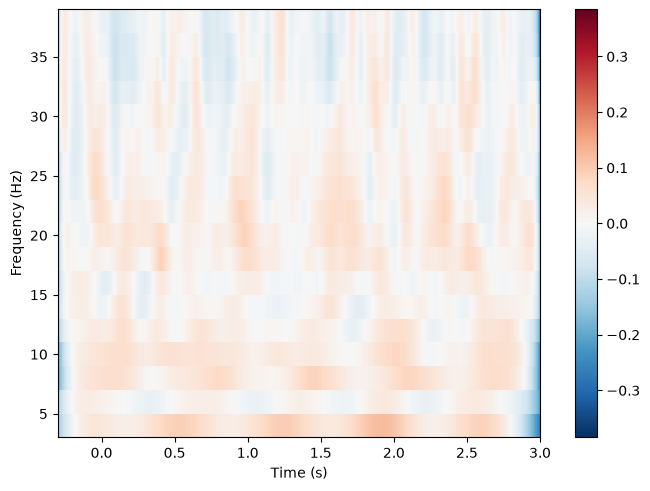

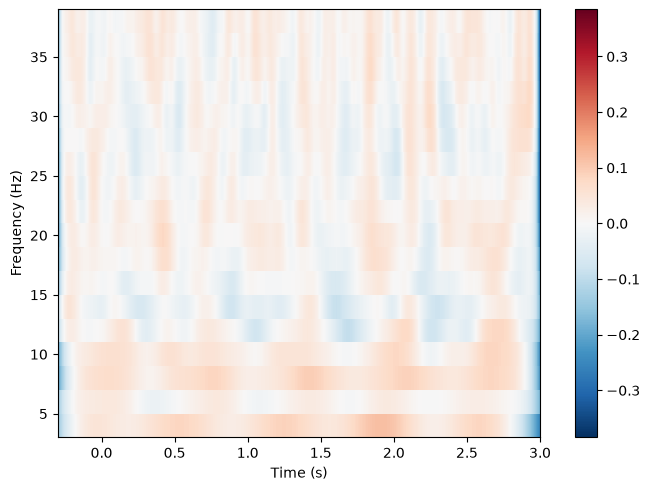

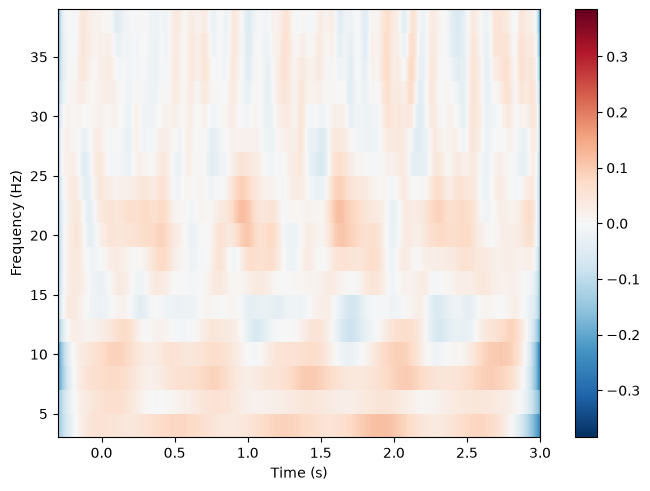

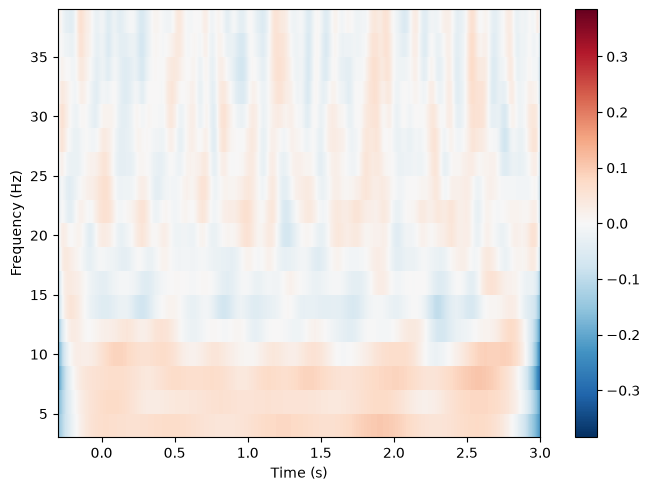

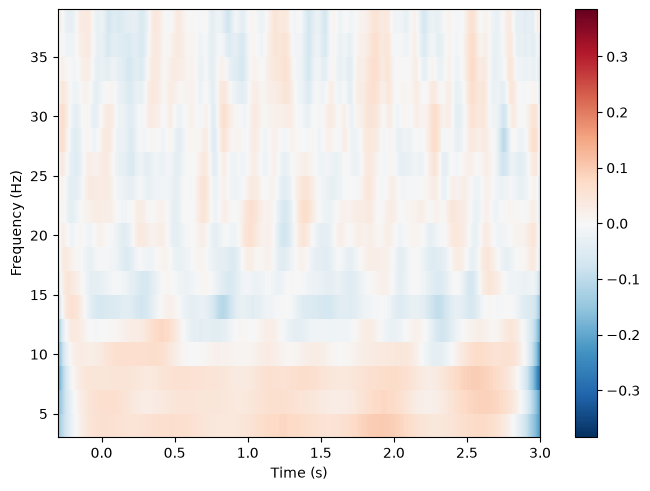

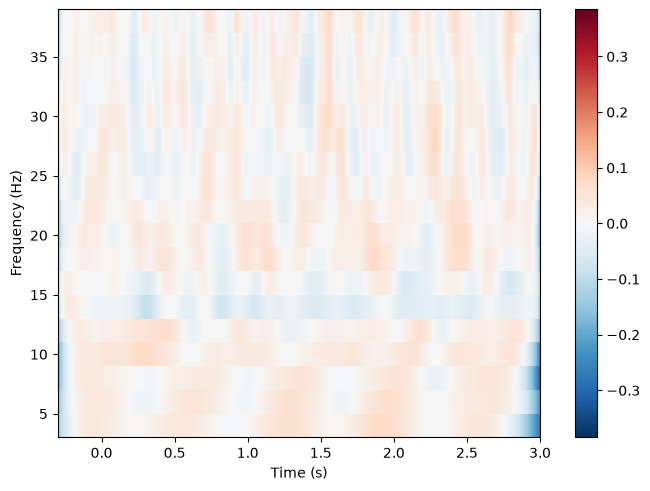

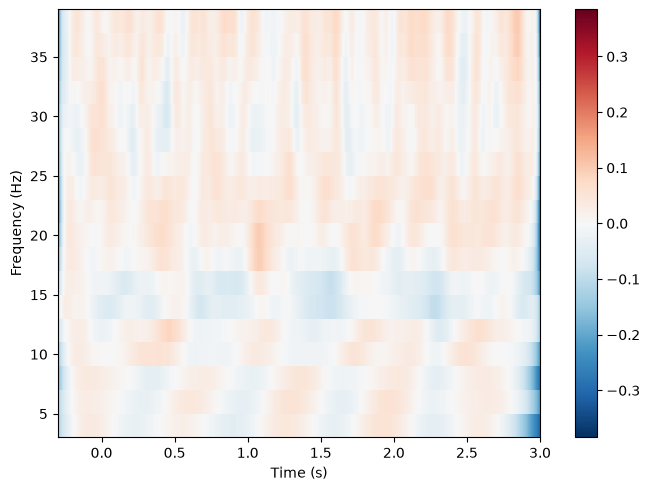

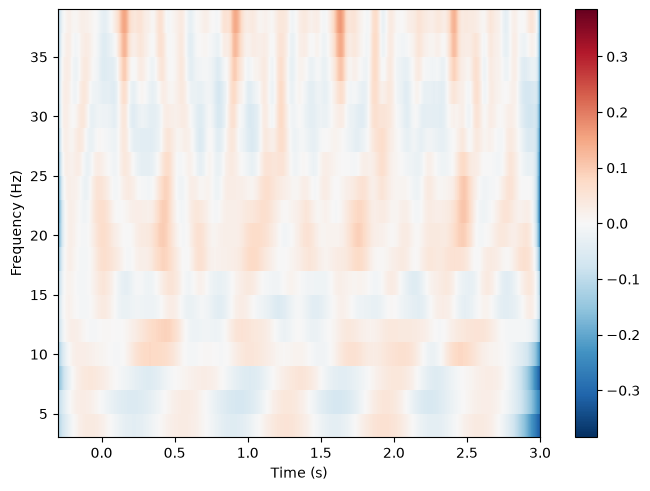

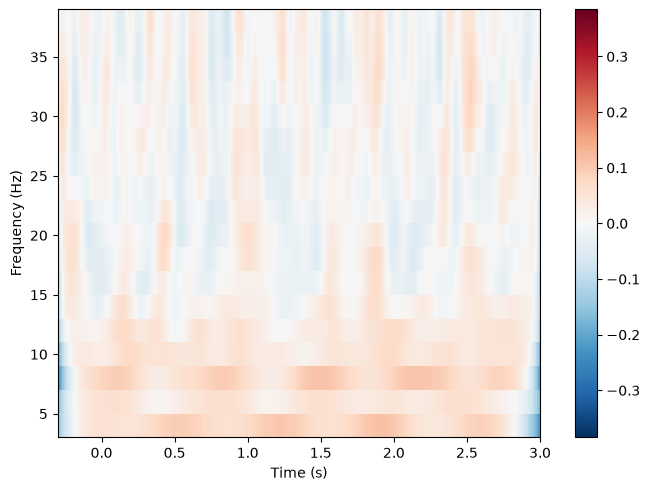

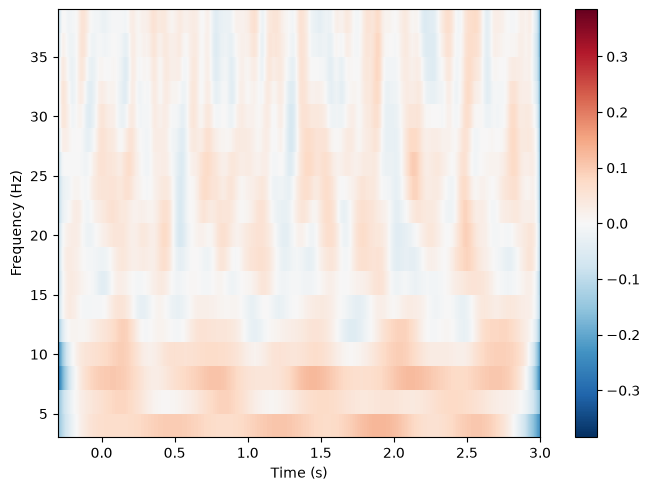

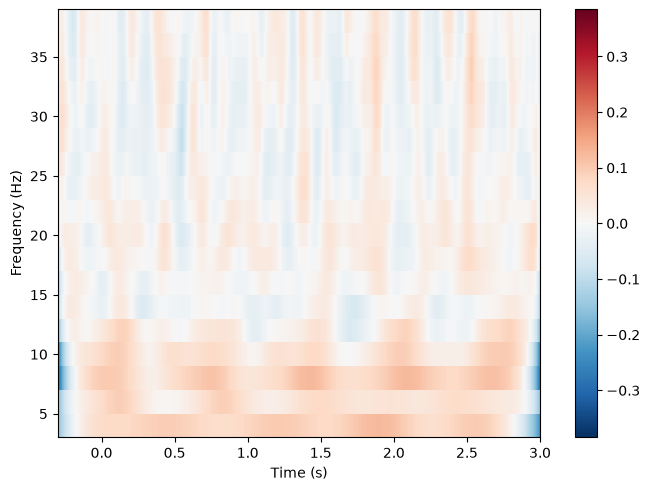

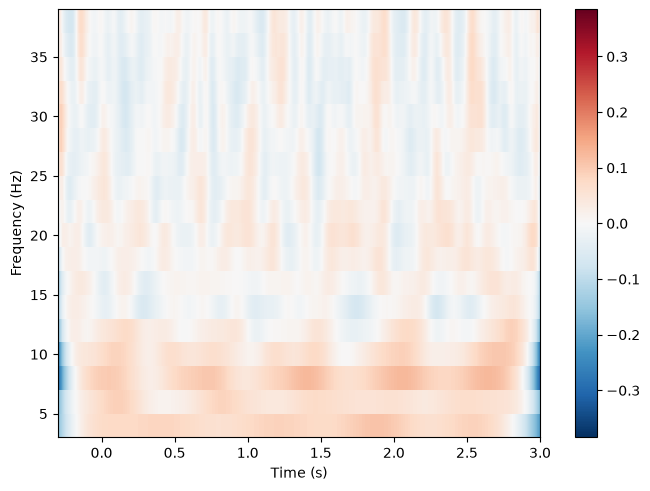

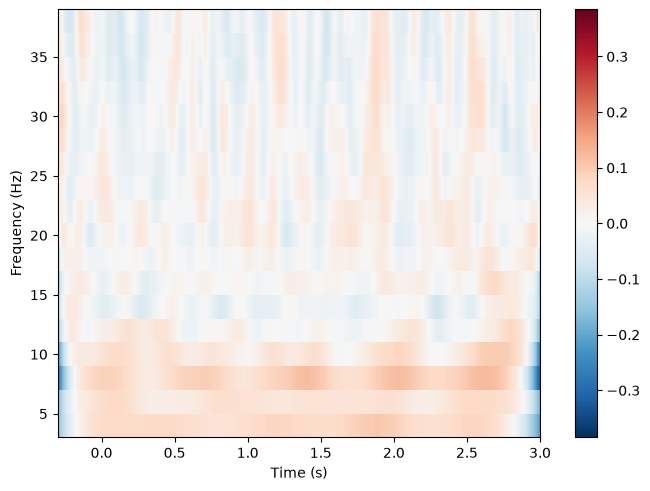

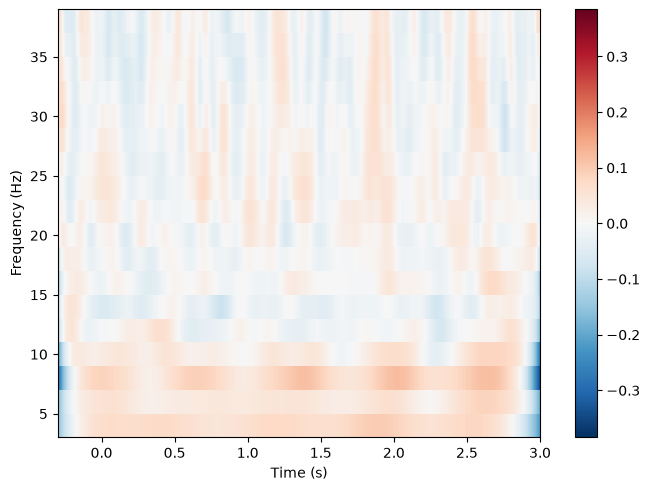

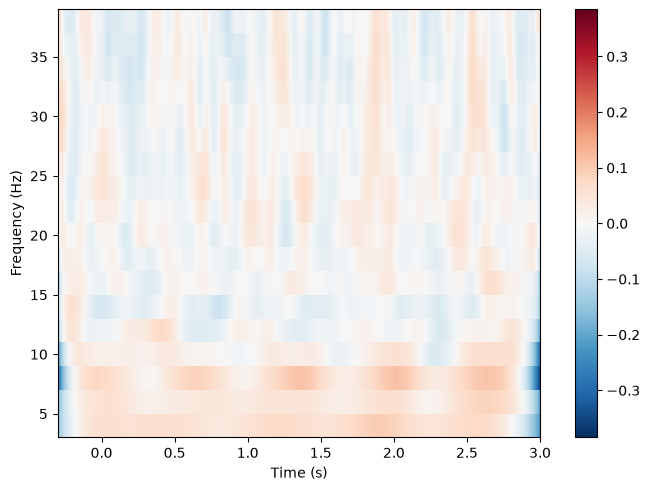

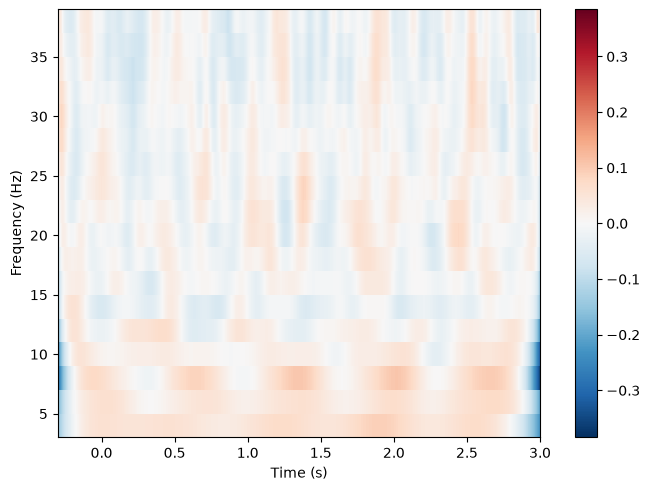

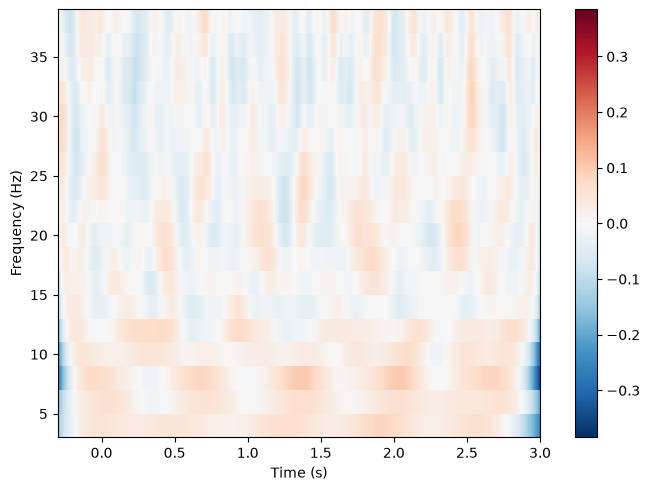

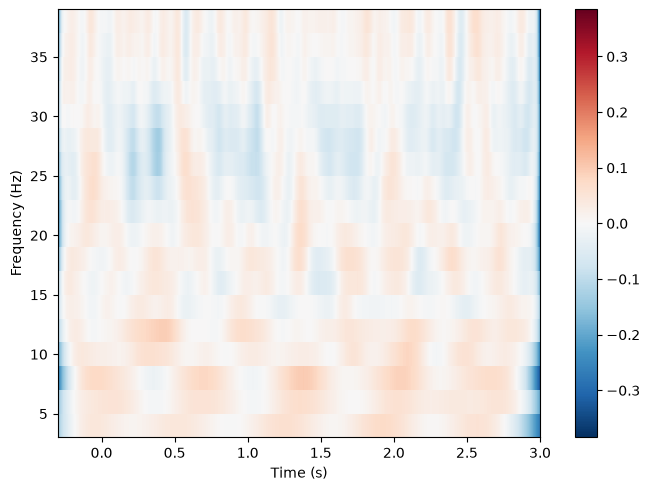

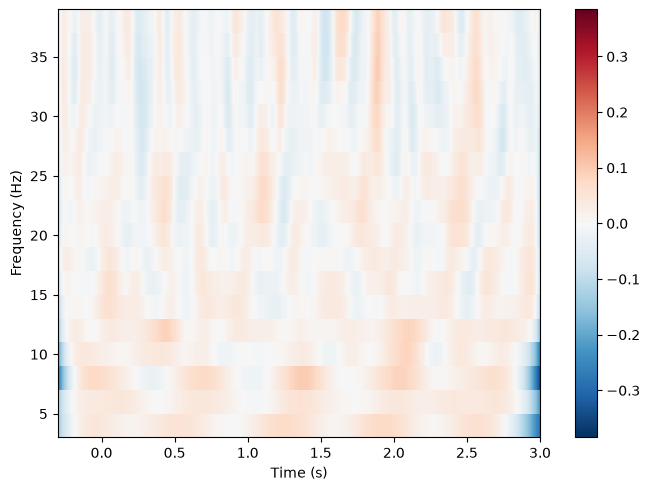

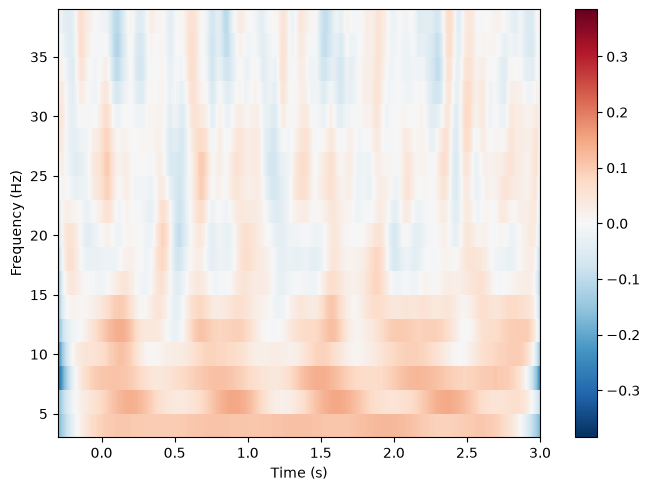

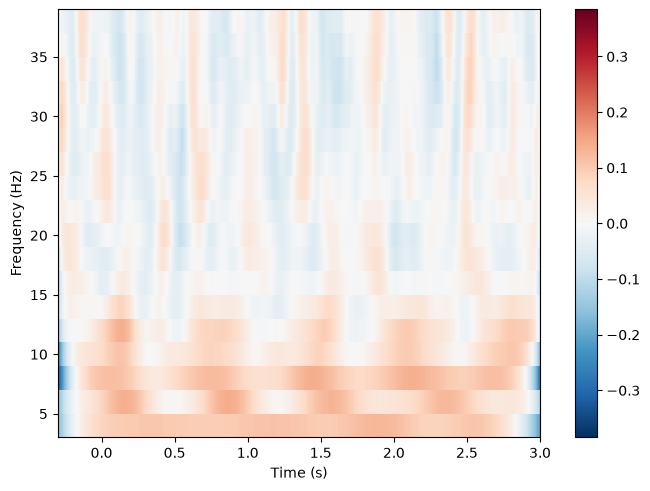

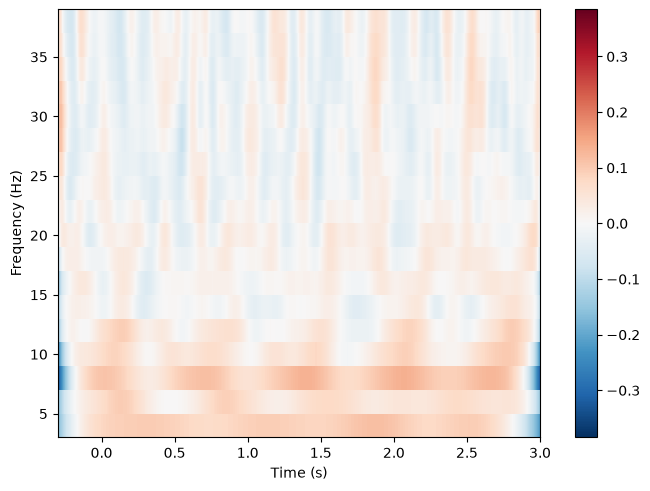

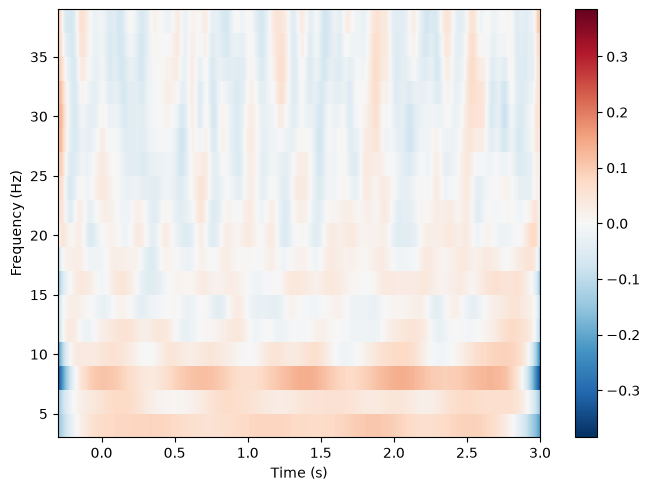

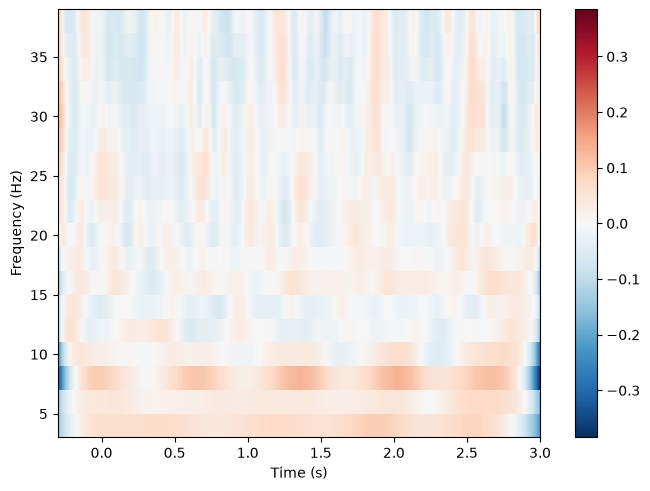

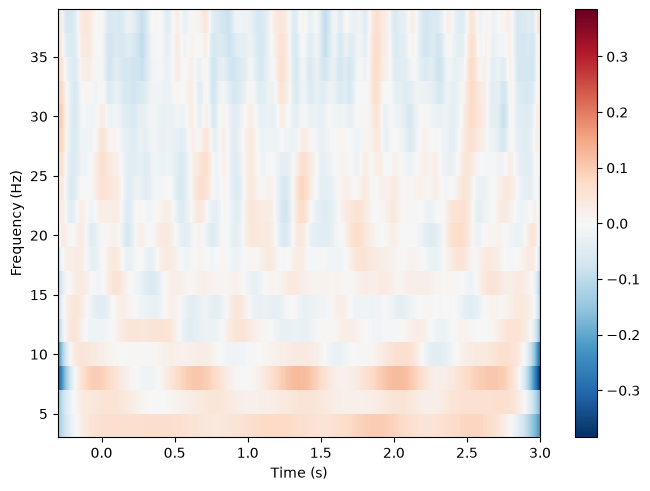

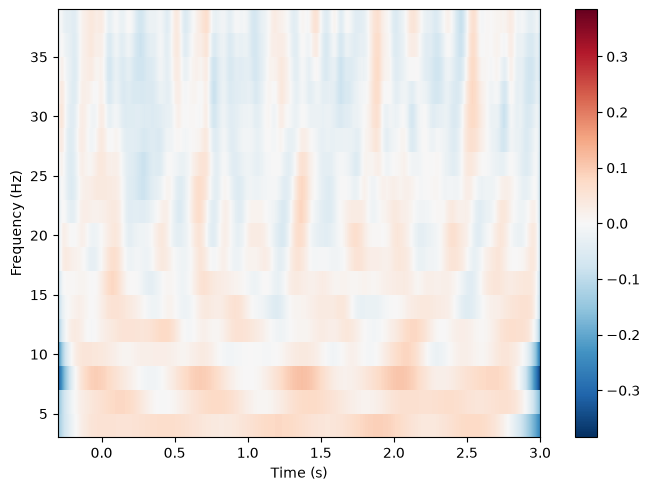

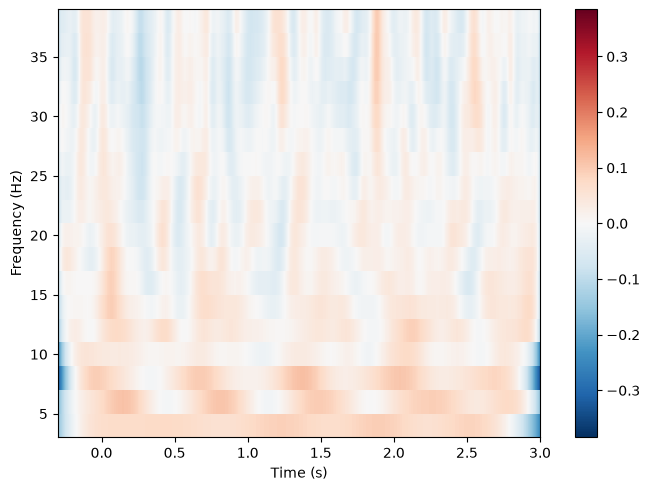

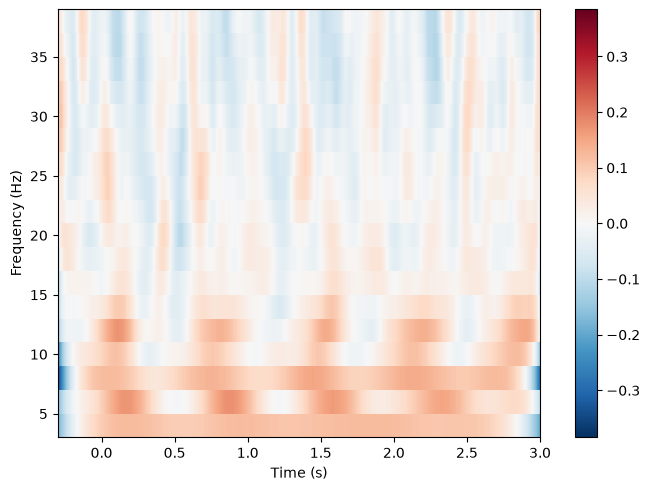

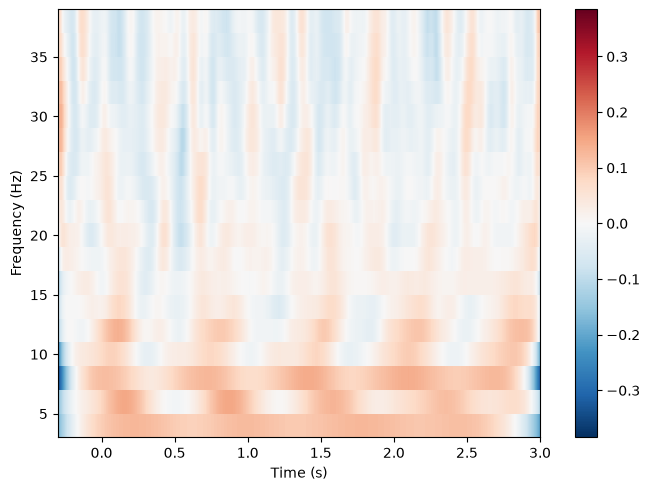

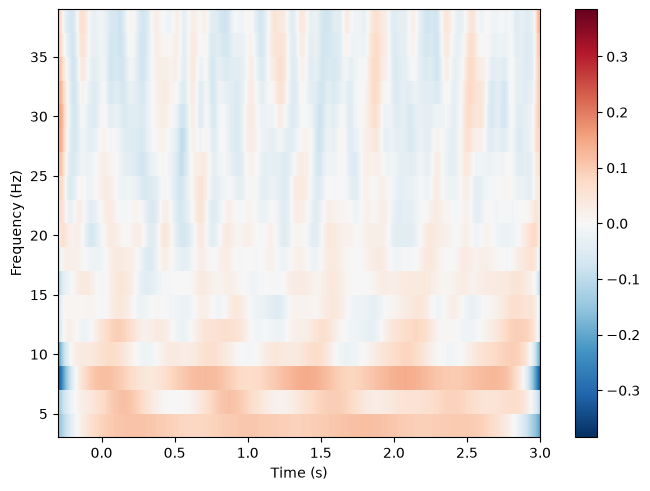

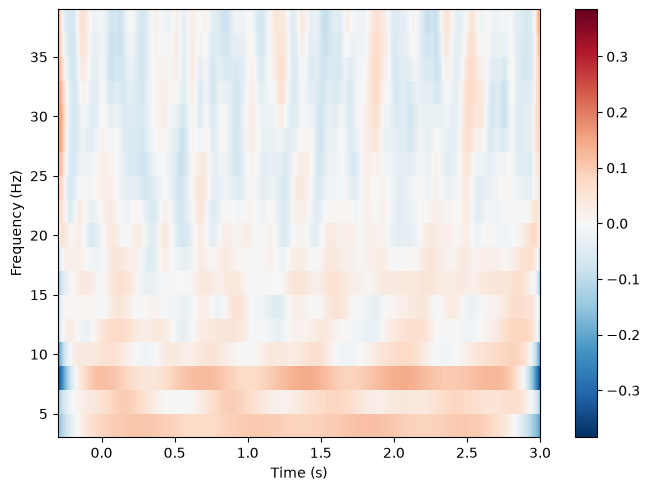

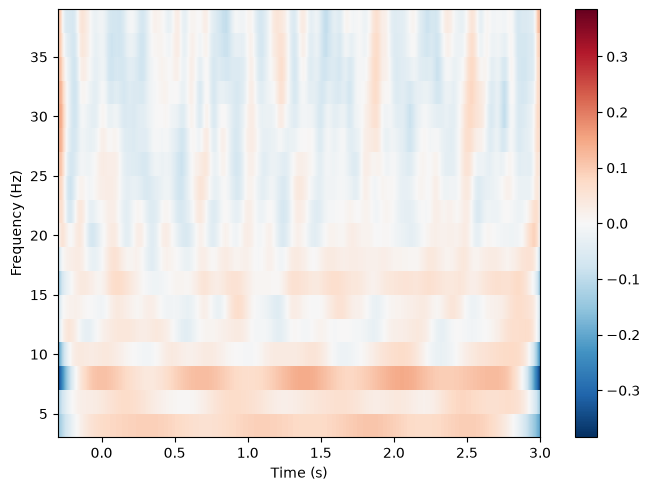

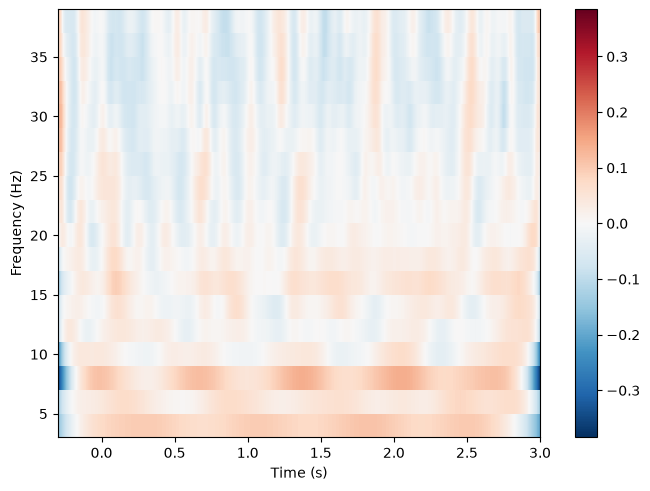

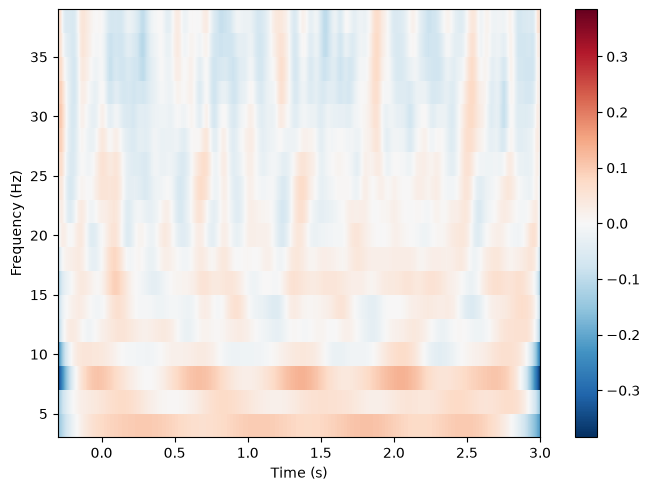

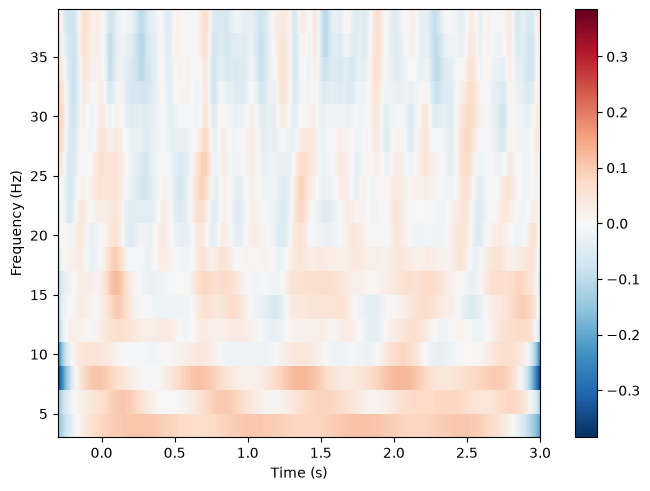

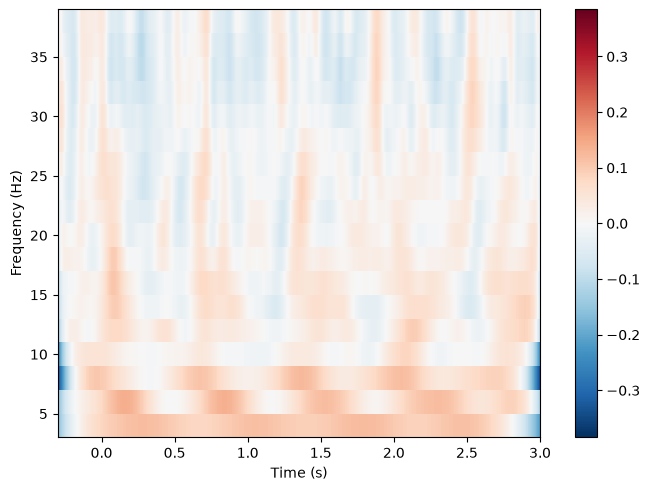

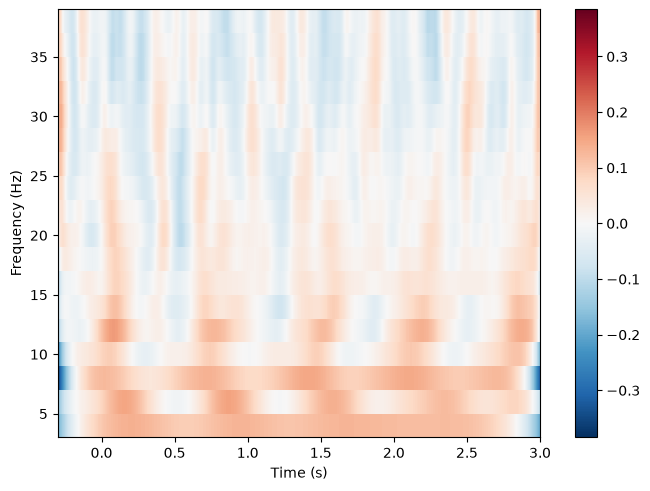

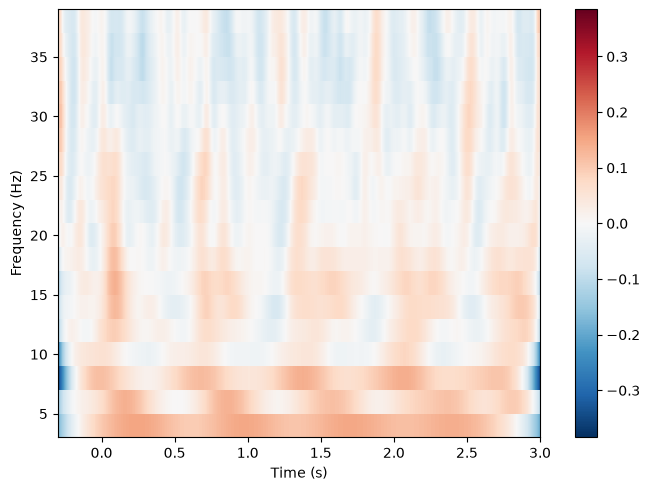

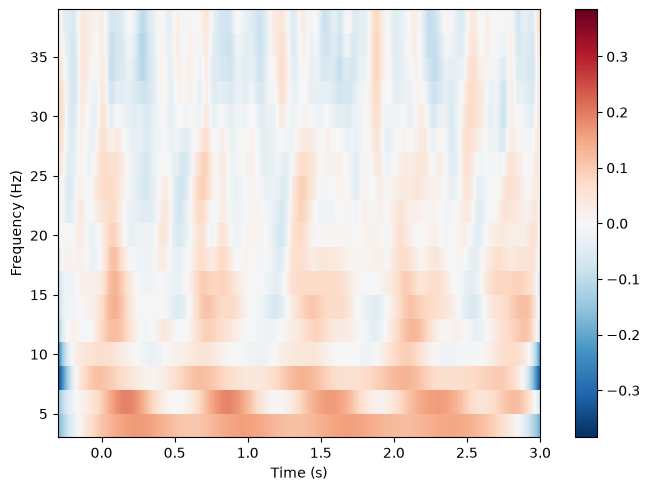

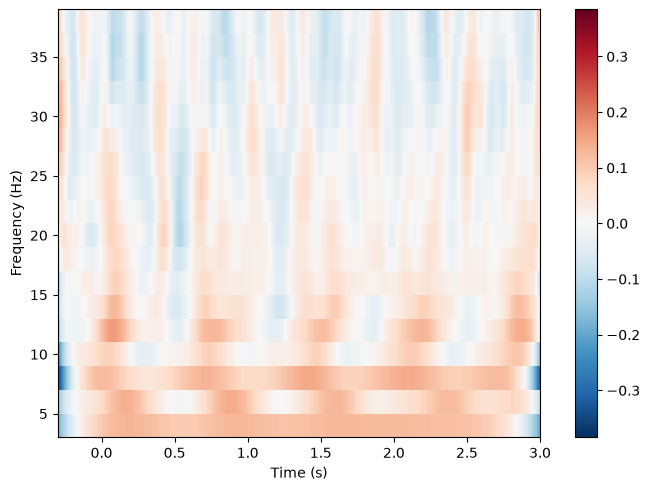

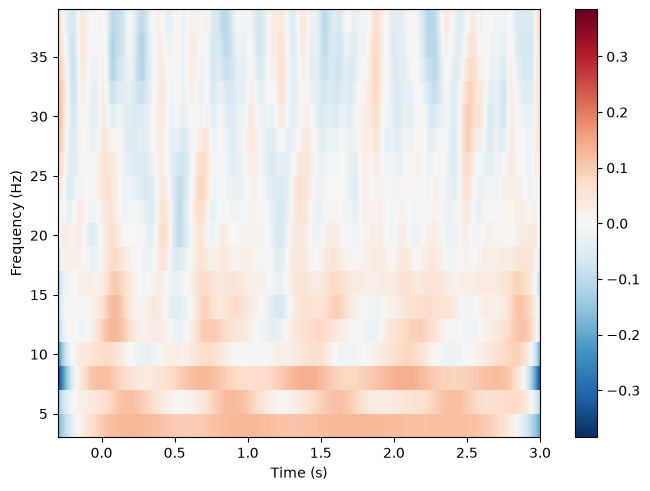

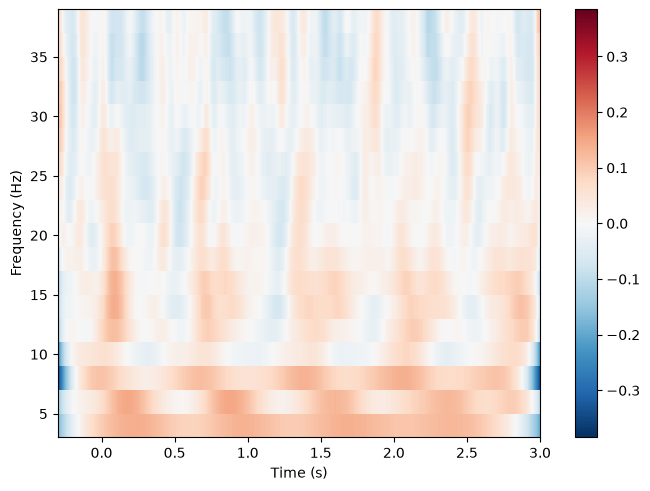

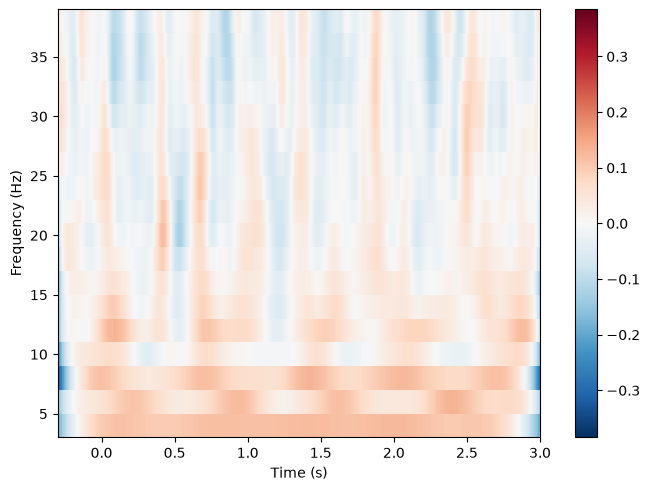

In [7]:
# Power recomputed here (not reused from M7) so this notebook's ITC/power
# comparison is self-contained: same epochs, same freqs, same n_cycles.
power = compute_tfr(epochs, freqs=freqs, n_cycles=7)
power_lr = power.copy().apply_baseline(baseline=(-0.3, 0), mode="logratio")
plot_tfr(power, baseline=(-0.3, 0), mode="logratio")

In [8]:
# Numeric grounding: locate the strongest ITC time-frequency cell (whole-
# scalp average) and check what power was doing at that same cell, and vice
# versa -- direct evidence for whether phase-locking and power line up or
# diverge here, instead of eyeballing two separate heatmaps.
post_stim = (itc.times >= 0) & (itc.times <= 2.5)

itc_avg = itc_bc.data[:, :, post_stim].mean(axis=0)      # channel-average -> (freqs, times)
power_avg = power_lr.data[:, :, post_stim].mean(axis=0)  # channel-average -> (freqs, times)
times_post = itc.times[post_stim]

itc_peak_idx = np.unravel_index(itc_avg.argmax(), itc_avg.shape)
power_peak_idx = np.unravel_index(power_avg.argmax(), power_avg.shape)

itc_peak_freq, itc_peak_time = freqs[itc_peak_idx[0]], times_post[itc_peak_idx[1]]
power_peak_freq, power_peak_time = freqs[power_peak_idx[0]], times_post[power_peak_idx[1]]

print(f"Strongest ITC: {itc_avg[itc_peak_idx]:.3f} at {itc_peak_freq:.0f} Hz, t={itc_peak_time:.2f}s")
print(f"  Power (logratio) at that same cell: {power_avg[itc_peak_idx]:.3f}")
print(f"Strongest power: {power_avg[power_peak_idx]:.3f} at {power_peak_freq:.0f} Hz, t={power_peak_time:.2f}s")
print(f"  ITC at that same cell: {itc_avg[power_peak_idx]:.3f}")

Strongest ITC: 0.107 at 6 Hz, t=0.13s
  Power (logratio) at that same cell: 0.043
Strongest power: 0.100 at 4 Hz, t=1.90s
  ITC at that same cell: -0.117


## ITC Interpretation

**What the plot shows:** Both the raw and baseline-corrected ITC heatmaps show phase-locking concentrated at low frequencies (theta/alpha, roughly 4-10 Hz) shortly after stimulus onset, then fading toward the noisier, uniformly low ITC that dominates the rest of the time-frequency plane. That's the expected signature of phase-resetting: consistency across trials should peak right when the stimulus resets the oscillation's phase, then decay back toward chance as trial-to-trial phase drifts apart again.

**Strongest phase-locking:** 0.107 at 6 Hz, t=0.13s (whole-scalp, all-channel average, baseline-corrected). That's modest in absolute terms, but it's diluted by two pooling choices: this is averaged across all 59 EEG channels — including many far from the sensory generators actually driving the response — and across all six pooled event types (auditory/visual/smiley/buttonpress) rather than one condition at a time. A single channel near auditory or visual cortex, on a single condition, would be expected to show a substantially higher peak than this whole-scalp, all-conditions average.

**Pre-stimulus baseline:** Baseline correction used `mode="mean"` over the -0.3-to-0s pre-stimulus window (not `logratio`, since ITC is already bounded in [0, 1] rather than open-ended like power — subtracting the pre-stimulus mean directly answers "how much did phase-locking rise above its own resting level," which is the natural question for a bounded quantity).

**Comparison to power:** The two peaks don't line up. At ITC's strongest cell (6 Hz, t=0.13s), power was barely above baseline (logratio +0.043) — phase reset with almost no accompanying power change. At power's strongest cell (4 Hz, t=1.90s, logratio +0.100), ITC was actually *below* its own baseline (-0.117) — a real, sizeable power increase with no elevated phase-locking to go with it.

**What this tells me physically:** The late 4 Hz power increase at t≈1.90s is a non-phase-locked, "induced" response — real oscillatory power that time-domain ERP averaging would cancel out (because it isn't phase-locked to the stimulus), and that a power-only TFR would show without being able to say whether it's phase-locked or not. This ITC analysis answers that question directly: at that specific cell, it is not. The early 6 Hz phase-locking near t=0.13s, despite being modest once diluted by whole-scalp/all-condition averaging, is consistent with an early sensory-evoked phase reset — the same underlying mechanism that lets trial-averaging recover a clean N100 in the ERP. Together, these two cells are a concrete demonstration that power and phase-locking are genuinely separable measurements of the same time-frequency plane, not two views of the same thing.